In [451]:
import numpy as np
import matplotlib.pylab as pl
import plotly.express as px
import plotly.graph_objects as go


from sklearn.datasets import make_multilabel_classification
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [452]:
n_samples = 100
n_classes = 10
n_labels = 3

control_level = 1 / (n_labels * 2)
print(control_level)

inputs, outputs = make_multilabel_classification(
    n_samples=n_samples,
    n_classes=n_classes,
    n_labels=n_labels,
    allow_unlabeled=False,
    return_indicator=True,
    random_state=1,
)
input_test, output_test = make_multilabel_classification(
    n_samples=1,
    n_classes=n_classes,
    n_labels=n_labels,
    allow_unlabeled=False,
    return_indicator=True,
    random_state=1,
)

inputs_train, inputs_calibration, outputs_train, outputs_calibration = train_test_split(
    inputs, outputs, test_size=0.5, random_state=42
)

input_scaler = StandardScaler()
scaled_inputs_train = input_scaler.fit_transform(inputs_train)
scaled_inputs_calibration = input_scaler.transform(inputs_calibration)
scaled_input_test = input_scaler.transform(input_test)

0.16666666666666666


In [453]:
regularization_grid = np.logspace(-3, 2, 100)
print(regularization_grid)

classifiers = [
    OneVsRestClassifier(LogisticRegression(C=regularization))
    for regularization in regularization_grid
]

[1.00000000e-03 1.12332403e-03 1.26185688e-03 1.41747416e-03
 1.59228279e-03 1.78864953e-03 2.00923300e-03 2.25701972e-03
 2.53536449e-03 2.84803587e-03 3.19926714e-03 3.59381366e-03
 4.03701726e-03 4.53487851e-03 5.09413801e-03 5.72236766e-03
 6.42807312e-03 7.22080902e-03 8.11130831e-03 9.11162756e-03
 1.02353102e-02 1.14975700e-02 1.29154967e-02 1.45082878e-02
 1.62975083e-02 1.83073828e-02 2.05651231e-02 2.31012970e-02
 2.59502421e-02 2.91505306e-02 3.27454916e-02 3.67837977e-02
 4.13201240e-02 4.64158883e-02 5.21400829e-02 5.85702082e-02
 6.57933225e-02 7.39072203e-02 8.30217568e-02 9.32603347e-02
 1.04761575e-01 1.17681195e-01 1.32194115e-01 1.48496826e-01
 1.66810054e-01 1.87381742e-01 2.10490414e-01 2.36448941e-01
 2.65608778e-01 2.98364724e-01 3.35160265e-01 3.76493581e-01
 4.22924287e-01 4.75081016e-01 5.33669923e-01 5.99484250e-01
 6.73415066e-01 7.56463328e-01 8.49753436e-01 9.54548457e-01
 1.07226722e+00 1.20450354e+00 1.35304777e+00 1.51991108e+00
 1.70735265e+00 1.917910

In [454]:
for classifier in classifiers:
    classifier.fit(scaled_inputs_train, outputs_train)

C:\Users\s623937\Documents\These\publication\conformal prediction\code\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\s623937\Documents\These\publication\conformal prediction\code\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\s623937\Documents\These\publication\conformal prediction\code\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\s623937\Documents\These\publication\conformal prediction\code\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\s623937\Documents\These\publication\conformal prediction\code\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(


In [455]:
probas_calibration = [
    classifier.predict_proba(scaled_inputs_calibration) for classifier in classifiers
]
proba_test = [
    classifier.predict_proba(scaled_input_test) for classifier in classifiers
]

In [438]:
def make_FNR_risk(outputs_calibration, probas):
    sample_size = outputs_calibration.shape[0]

    def FNR_risk(q_value):
        return (
            (np.logical_and(outputs_calibration, probas < 1 - q_value)).sum(axis=1)
            / outputs_calibration.sum(axis=1)
        ).mean()

    def upper_FNR_risk(q_value):
        return (1.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    def lower_FNR_risk(q_value):
        return (0.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    return FNR_risk, upper_FNR_risk, lower_FNR_risk

def dichotomy_search(f_values):
    cardinal = f_values.shape[0]
    left_index = 0
    right_index = cardinal - 1

    f_right = f_values[right_index]
    f_left = f_values[left_index]

    if f_right * f_left > 0:
        if f_left > 0:
            return right_index
        else:
            return left_index

    while (right_index - left_index) >= 2:
        middle_index = max(
            min(np.int64((left_index + right_index) / 2), right_index), left_index
        )
        f_middle = f_values[middle_index]

        # print("left", left_index, f_left)
        # print("middle", middle_index, f_middle)
        # print("right", right_index, f_right)

        if (f_middle == 0) or (f_left * f_middle < 0):
            right_index = middle_index
            f_right = f_middle
        else:
            left_index = middle_index
            f_left = f_middle

    if f_left * f_right < 0:
        return right_index
    else:
        return left_index

In [440]:
index = -1
probas = probas_calibration[index]
q_values = np.sort(probas.flatten())

In [441]:
FNR_risk, upper_FNR_risk, lower_FNR_risk = make_FNR(outputs_calibration, probas)
upper_fnr_risk_values = np.array([upper_FNR_risk(q_value) for q_value in q_values])
upper_quantile_index = dichotomy_search(upper_fnr_risk_values - control_level)
lower_fnr_risk_values = np.array([lower_FNR_risk(q_value) for q_value in q_values])
lower_quantile_index = dichotomy_search(lower_fnr_risk_values - control_level)

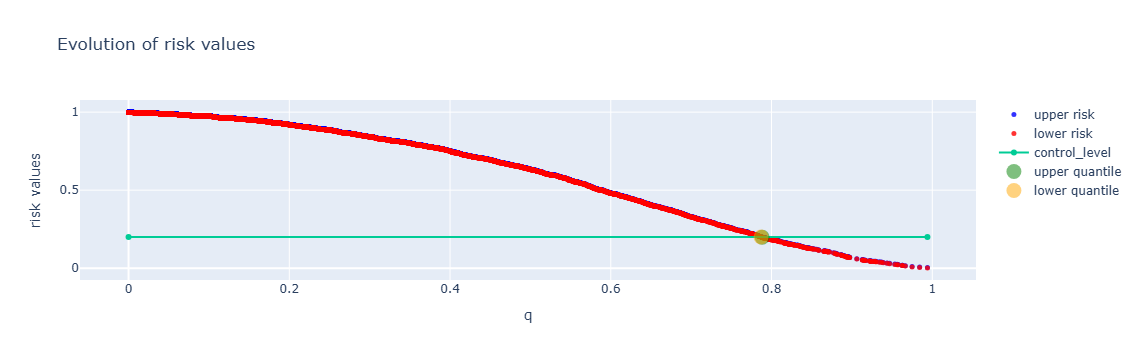

In [442]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=q_values,
        y=upper_fnr_risk_values,
        name="upper risk",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="blue",  # Set the marker color
            opacity=0.8,  # Set the marker opacity
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=q_values,
        y=lower_fnr_risk_values,
        name="lower risk",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="red",  # Set the marker color
            opacity=0.8,  # Set the marker opacity
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=[q_values[0], q_values[-1]],
        y=[control_level, control_level],
        name="control_level",
    )
)
fig.add_trace(
    go.Scatter(
        x=[q_values[upper_quantile_index]],
        y=[upper_fnr_risk_values[upper_quantile_index]],
        name="upper quantile",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=15,  # Set the marker size
            color="green",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=[q_values[lower_quantile_index]],
        y=[lower_fnr_risk_values[lower_quantile_index]],
        name="lower quantile",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=15,  # Set the marker size
            color="orange",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)
fig.update_layout(
    title="Evolution of risk values",
    xaxis_title="q",
    yaxis_title="risk values",
)
fig.show()

In [443]:
q_values_ = [
    np.sort(probas.flatten())
    for probas in probas_calibration
]

oracle_q_values_ = [
    np.sort((
        np.concatenate((probas, proba))
    ).flatten())
    for probas, proba in zip(probas_calibration, proba_test)
]

risks = [
    make_FNR(outputs_calibration, probas)
    for probas in probas_calibration
]

oracle_risks = [
    make_FNR(
        np.concatenate((outputs_calibration, output_test)),
        np.concatenate((probas, proba))
    )[0] for probas, proba in zip(probas_calibration, proba_test)
]

In [444]:
lower_fnr_risk_values_ = [
    np.array([FNR_risk[-1](q_value) for q_value in q_values])
    for FNR_risk, q_values in zip(risks, q_values_)
]

upper_fnr_risk_values_ = [
    np.array([FNR_risk[1](q_value) for q_value in q_values])
    for FNR_risk, q_values in zip(risks, q_values_)
]

oracle_fnr_risk_values_ = [
    np.array([oracle_FNR_risk(q_value) for q_value in q_values])
    for oracle_FNR_risk, q_values in zip(oracle_risks, oracle_q_values_)
]

In [445]:
lower_quantile_indices = [
    dichotomy_search(lower_fnr_risk_values - control_level)
    for lower_fnr_risk_values in lower_fnr_risk_values_
]

upper_quantile_indices = [
    dichotomy_search(upper_fnr_risk_values - control_level)
    for upper_fnr_risk_values in upper_fnr_risk_values_
]

oracle_quantile_indices = [
    dichotomy_search(oracle_fnr_risk_values - control_level)
    for oracle_fnr_risk_values in oracle_fnr_risk_values_
]

In [446]:
lower_quantile_values = [
    q_values[lower_quantile_index]
    for q_values, lower_quantile_index in zip(q_values_, lower_quantile_indices)
]

upper_quantile_values = [
    q_values[upper_quantile_index]
    for q_values, upper_quantile_index in zip(q_values_, upper_quantile_indices)
]

oracle_quantile_values = [
    q_values[oracle_quantile_index]
    for q_values, oracle_quantile_index in zip(oracle_q_values_, oracle_quantile_indices)
]

In [447]:
lower_volumes = np.array([
    (np.concatenate((probas, proba)) >= 1 - lower_quantile_value).sum(axis = 1).mean()
    for probas, proba, lower_quantile_value in zip(probas_calibration, proba_test, lower_quantile_values)
])

upper_volumes = np.array([
    (np.concatenate((probas, proba)) >= 1 - upper_quantile_value).sum(axis = 1).mean()
    for probas, proba, upper_quantile_value in zip(probas_calibration, proba_test, upper_quantile_values)
])

min_upper_volumes = upper_volumes.min()

oracle_volumes = np.array([
    (np.concatenate((probas, proba)) >= 1 - oracle_quantile_value).sum(axis = 1).mean()
    for probas, proba, oracle_quantile_value in zip(probas_calibration, proba_test, oracle_quantile_values)
])

min_upper_volumes = upper_volumes.min()

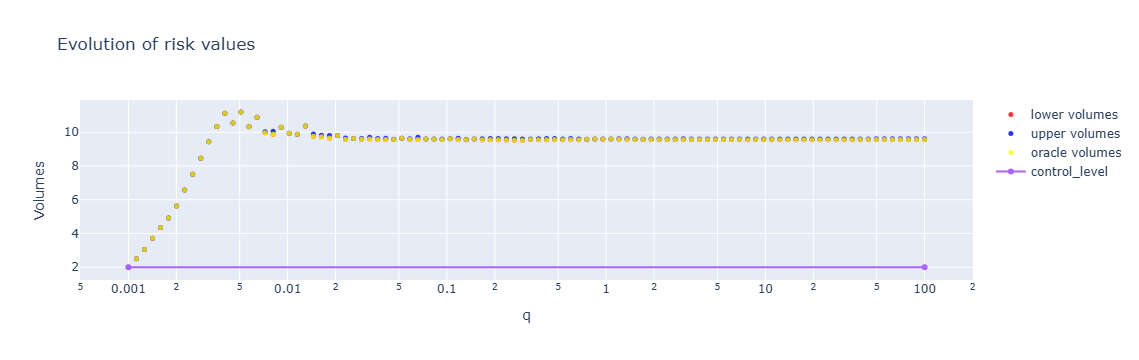

In [448]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=regularization_grid,
        y=lower_volumes,
        name="lower volumes",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="red",  # Set the marker color
            opacity=0.8,  # Set the marker opacity
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=regularization_grid,
        y=upper_volumes,
        name="upper volumes",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="blue",  # Set the marker color
            opacity=0.8,  # Set the marker opacity
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=regularization_grid,
        y=oracle_volumes,
        name="oracle volumes",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="yellow",  # Set the marker color
            opacity=0.8,  # Set the marker opacity
        ),
    )
)



fig.add_trace(
    go.Scatter(
        x=[regularization_grid[0], regularization_grid[-1]],
        y=[min_upper_volumes, min_upper_volumes],
        name="control_level",
    )
)

fig.update_layout(
    title="Evolution of risk values",
    xaxis_title="q",
    yaxis_title="Volumes",
)
fig.update_xaxes(type="log")
fig.show()

In [449]:
modelSel_set = np.arange(regularization_grid.shape[0])[lower_volumes <= min_upper_volumes]
modelSel_prediction_set = np.concatenate(tuple([
    proba_test[index] >= 1 - upper_quantile_values[index] for index in modelSel_set
])).any(axis=0)
print(output_test)
print(modelSel_prediction_set)
print(modelSel_prediction_set.sum())

[[0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]]
[False False False False False False False False False False False False
 False  True False False False False False False]
1


In [450]:
oracle_set = np.argmin(oracle_volumes)
oracle_prediction_set = proba_test[oracle_set] >= 1 - oracle_quantile_values[oracle_set]
print(output_test)
print(oracle_prediction_set)
print(oracle_prediction_set.sum())

[[0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]]
[[False False False False False False False False False False False False
  False  True False False False False False False]]
1
